<a href="https://colab.research.google.com/github/rodrigo-rg/pucrio.sprint4.mvp/blob/main/House_Price_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MVP - Aluno: Rodrigo Rodrigues Gonçalves

Engenharia de Sistemas de Software

Sprint 4 - Qualidade de Software, Segurança e Sistemas Inteligentes

In [ ]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
# Usada para manipulação e análise de dados, especialmente com DataFrames.
import pandas as pd
# Fornece suporte para arrays e matrizes, e funções matemáticas de alto nível para operar sobre eles.
import numpy as np
# Usada para serializar e desserializar objetos Python, permitindo salvar modelos e scalers em arquivos.
import pickle
# Usada para criar visualizações estáticas, interativas e animadas em Python.
import matplotlib.pyplot as plt
# Utilizada para padronizar as features, escalando-as para ter média 0 e variância 1.
from sklearn.preprocessing import StandardScaler
# Utilizada para normalizar as features, escalando-as para um intervalo específico (geralmente entre 0 e 1).
from sklearn.preprocessing import MinMaxScaler
# Função para dividir arrays ou matrizes em conjuntos de treino e teste aleatórios.
from sklearn.model_selection import train_test_split
# Fornece índices de treino/teste para divisão de dados em k dobras (folds) para validação cruzada.
from sklearn.model_selection import KFold
# Uma versão do KFold que retorna dobras estratificadas, ou seja, preserva a porcentagem de amostras para cada classe.
from sklearn.model_selection import StratifiedKFold
# Utilizada para avaliar o desempenho de um modelo usando validação cruzada.
from sklearn.model_selection import cross_val_score
# Realiza uma busca exaustiva sobre valores de parâmetros especificados para um estimador, usando validação cruzada.
from sklearn.model_selection import GridSearchCV
# Função para calcular a acurácia da classificação.
from sklearn.metrics import accuracy_score
# Usada para encadear múltiplas etapas de processamento de dados e estimadores em um único objeto.
from sklearn.pipeline import Pipeline

# Implementa o algoritmo de Árvore de Decisão para classificação.
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
from sklearn.tree import DecisionTreeClassifier
# Implementa o algoritmo K-Nearest Neighbors (KNN) para classificação.
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
from sklearn.neighbors import KNeighborsClassifier
# Implementa o algoritmo Naive Bayes Gaussiano para classificação.
# https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html
from sklearn.naive_bayes import GaussianNB
# Implementa o algoritmo de Regressão Logística, um classificador linear.
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
from sklearn.linear_model import LogisticRegression


## Carga de dados

Este projeto implementa um classificador de faixas de preço imobiliário utilizando um dataset contendo 5 atributos preditivos:
1. Tamanho em "pés quadrados"
2. Quantidade de quartos
3. Quantidade de banheiros
4. Localização (1 = Rural ; 2 = Urbano ; 3 = Suburbano)
5. Ano de construção

O arquivo csv original foi alterado de forma que a valor dos imóveis fosse substituído por faixas de valores (Price_Range), de forma a ser possível adaptar o dataset para um problema de classificação.

Estas são as faixas de valores, ou seja, as classes da coluna Price_Range:
- Faixa 1: entre       0 e  49.999 USD
- Faixa 2: entre  50.000 e  99.999 USD
- Faixa 3: entre 100.000 e 149.999 USD
- Faixa 4: entre 150.000 e 199.999 USD
- Faixa 5: entre 200.000 e 249.999 USD
- Faixa 6: entre 250.000 e 299.999 USD
- Faixa 7: entre 300.000 e 349.999 USD
- Faixa 8: entre 350.000 e 399.999 USD
- Faixa 9: entre 400.000 e 449.999 USD

In [ ]:
# Arquivo do dataset
url = "../data/house_price_dataset.csv"
# Mais informações: https://www.kaggle.com/datasets/muhammadbinimran/housing-price-prediction-data/data

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')

# Mostra as primeiras linhas do dataset
dataset.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price_Range
0,2126,4,1,1,1969,5
1,2459,3,2,1,1980,4
2,1860,2,1,3,1970,7
3,2294,2,1,2,1996,5
4,2130,5,2,3,2001,6


## Separação entre treino e teste (holdout)

80% dos dados serão utilizados para treino dos modelos, e 20% serão utilizados para teste.
Será feita a validação cruzada estratificada em 10 folds.

In [ ]:
test_size = 0.20 # 20% para teste, 80% para treino
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = dataset.values
X = array[:,0:5] # Variáveis preditoras
y = array[:,5] # Variável dependente

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size, # Tamanho do teste.
    shuffle=True, # É sempre bom embaralhar.
    random_state=seed,
    stratify=y) # holdout com estratificação
# Holdout: divide uma vez em treino e teste
# Estratificação: mantém a proporção das classes

# Parâmetros e partições da validação cruzada
scoring = 'accuracy' # Métrica de avaliação: acurácia
num_particoes = 10
# Validação cruzada com estratificação
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

O objetivo é classificar imóveis em 9 faixas de preço distintas. Na fase de avaliação da linha base, quatro algoritmos serão testados: K-Nearest Neighbors (KNN), Decision Tree (CART), Naive Bayes Gaussiano (NB) e Regressão Logística (LR).

KNN: 0.299100 (0.005782)
CART: 0.266400 (0.006954)
NB: 0.363400 (0.007200)
LR: 0.364400 (0.007544)


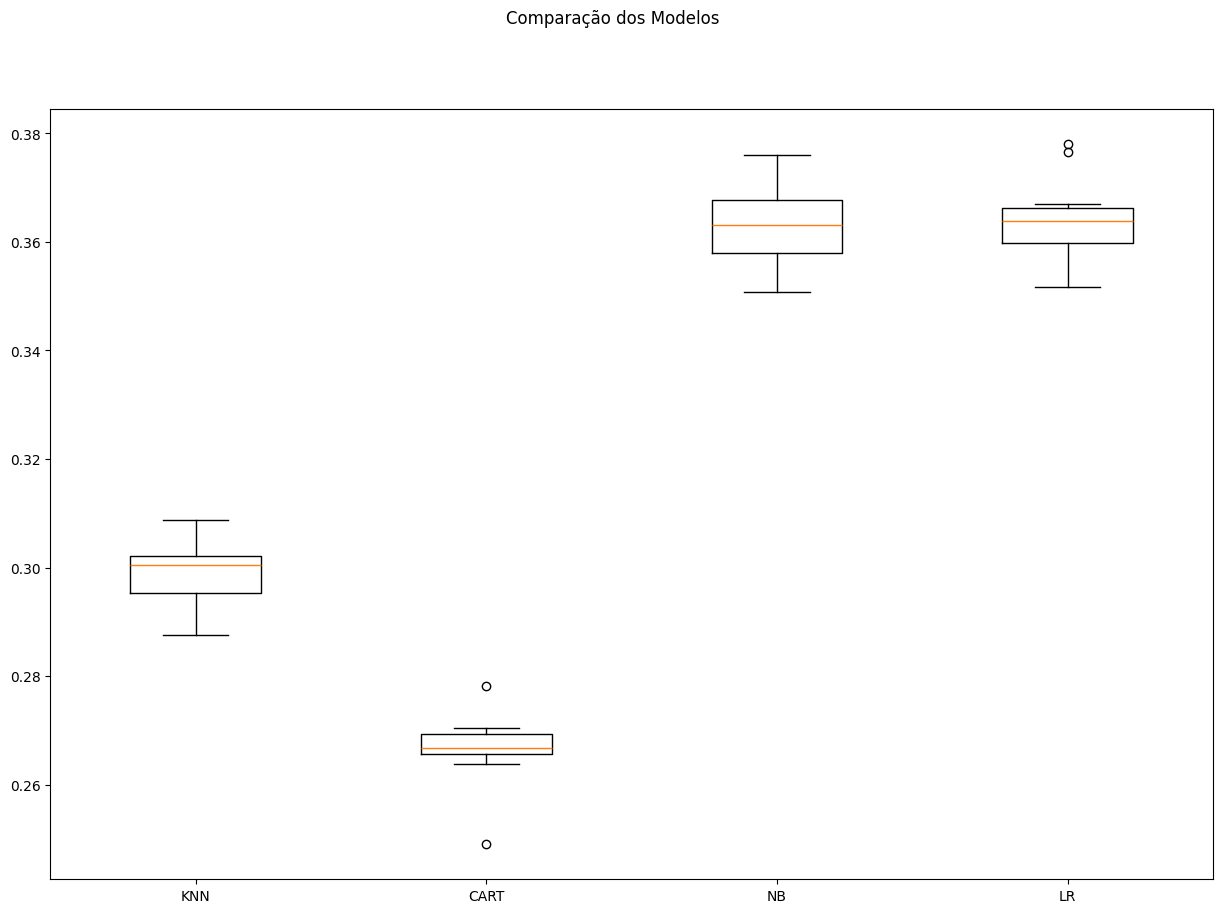

In [ ]:
np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('LR', LogisticRegression()))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

Os resultados iniciais mostraram que o algoritmo de Regressão Logística (LR) apresentou o melhor desempenho dentre os modelos, alcançando uma acurácia em torno de 36%.

### Criação e avaliação de modelos: dados padronizados e normalizados

KNN-orig: 0.299 (0.006)
CART-orig: 0.266 (0.007)
NB-orig: 0.363 (0.007)
LR-orig: 0.364 (0.008)
KNN-padr: 0.296 (0.005)
CART-padr: 0.267 (0.006)
NB-padr: 0.363 (0.007)
LR-padr: 0.369 (0.008)
KNN-norm: 0.297 (0.005)
CART-norm: 0.269 (0.007)
NB-norm: 0.363 (0.007)
LR-norm: 0.369 (0.008)


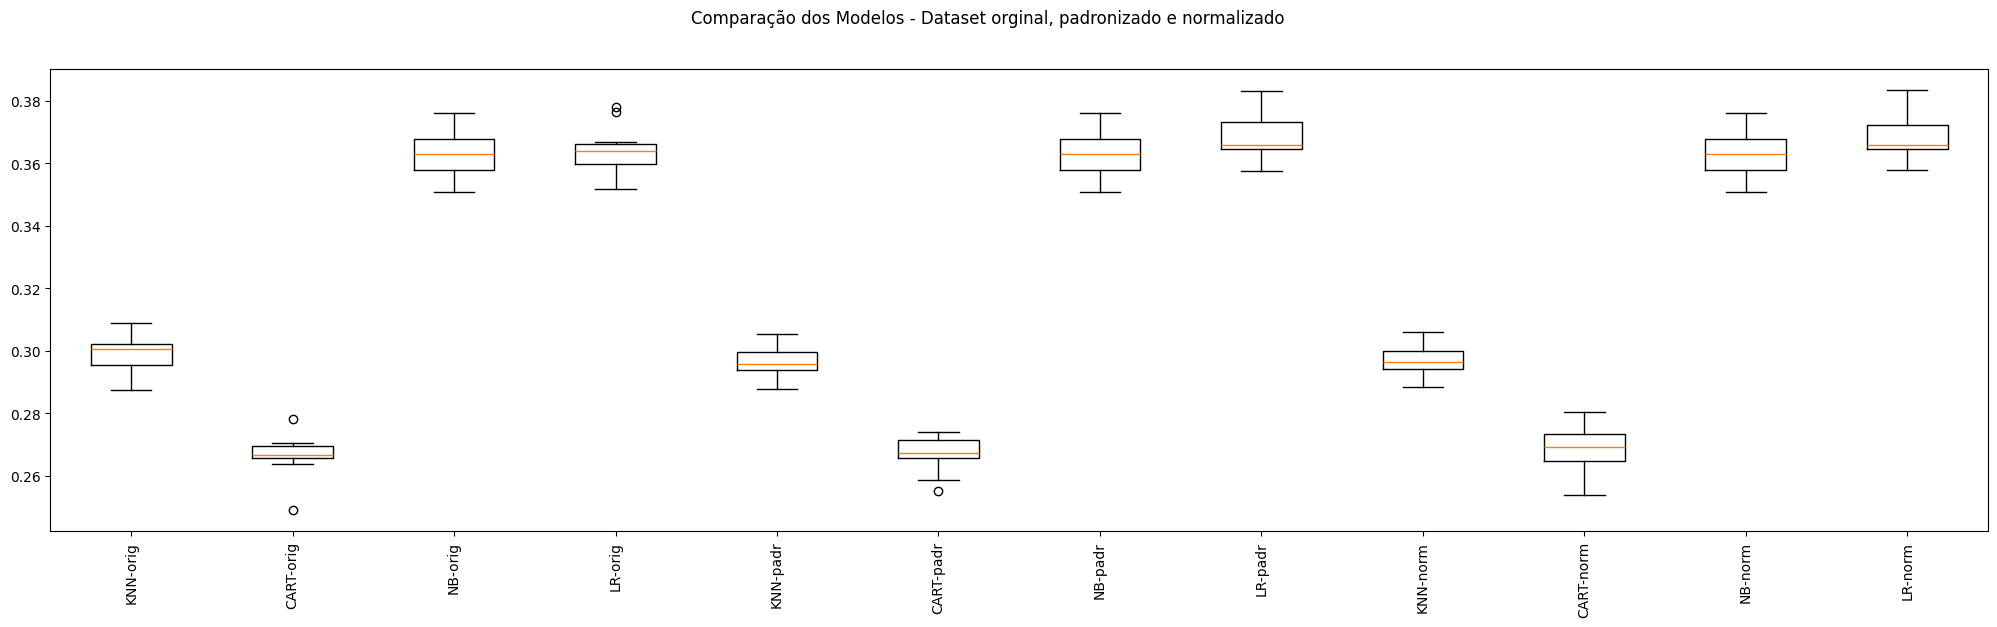

In [ ]:
# Definindo uma semente global para este bloco
np.random.seed(7)

# Listas para armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
lr = ('LR', LogisticRegression())

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('LR-orig', Pipeline([lr])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('LR-padr', Pipeline([standard_scaler, lr])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('LR-norm', Pipeline([min_max_scaler, lr])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

A investigação da influência de técnicas de normalização e padronização dos dados revelou melhorias significativas em praticamente todos os algoritmos. Os modelos submetidos a escalamento ("scaler") apresentaram, de forma geral, um desempenho superior em comparação com os dados brutos, sendo o StandardScaler (padronização) a técnica mais eficaz. O MinMaxScaler (normalização) também proporcionou ganhos, porém menores que o StandardScaler.

### Otimização dos hiperparâmetros

A otimização de hiperparâmetros via GridSearchCV será realizada para os algoritmos de melhor desempenho, que foram o Naive Bayes (NB) e Regressão Logística (LR).

In [ ]:
# Tuning do Naive Bayes (NB)

np.random.seed(7) # definindo uma semente global para este bloco

pipelines = []

# Definindo os componentes do pipeline
nb = ('NB', GaussianNB()) # Changed from LR to NB
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('nb-orig', Pipeline(steps=[nb])))
pipelines.append(('nb-padr', Pipeline(steps=[standard_scaler, nb])))
pipelines.append(('nb-norm', Pipeline(steps=[min_max_scaler, nb])))

param_grid = {
    'NB__var_smoothing': np.logspace(0, -9, num=100) # Parameter for GaussianNB
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Tuning NB - %s: Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))


Tuning NB - nb-orig: Melhor: 0.365025 usando {'NB__var_smoothing': np.float64(0.0533669923120631)}
Tuning NB - nb-padr: Melhor: 0.365025 usando {'NB__var_smoothing': np.float64(0.02848035868435802)}
Tuning NB - nb-norm: Melhor: 0.364850 usando {'NB__var_smoothing': np.float64(0.01519911082952933)}


In [ ]:
# Tuning da Regressão Logística (LR)

np.random.seed(7) # definindo uma semente global para este bloco

pipelines = []

# Definindo os componentes do pipeline
lr = ('LR', LogisticRegression())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('lr-orig', Pipeline(steps=[lr])))
pipelines.append(('lr-padr', Pipeline(steps=[standard_scaler, lr])))
pipelines.append(('lr-norm', Pipeline(steps=[min_max_scaler, lr])))

param_grid = {
    'LR__solver': ['lbfgs', 'liblinear'],
    'LR__C': [0.1, 1.0, 5.0],
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Tuning LR - %s: Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Tuning LR - lr-orig: Melhor: 0.364400 usando {'LR__C': 1.0, 'LR__solver': 'lbfgs'}
Tuning LR - lr-padr: Melhor: 0.368925 usando {'LR__C': 1.0, 'LR__solver': 'lbfgs'}
Tuning LR - lr-norm: Melhor: 0.368700 usando {'LR__C': 1.0, 'LR__solver': 'lbfgs'}


Após a otimização de hiperparâmetros, o algoritmo de Regressão Logística (LR) foi o que apresentou melhor desempenho. Testaram-se diferentes solvers ('lbfgs' e 'liblinear') e valores de C (0.1, 1.0, 5.0), identificando C=1.0 com solver='lbfgs' como a melhor configuração.

## Finalização do Modelo

O modelo final será integrado em um pipeline com o StandardScaler.

In [ ]:
# Avaliação do modelo com o conjunto de testes

# Preparação do modelo

# Scaler escolhido foi o padrão (standard). Ajuste do scaler com o conjunto de treino.
scaler = StandardScaler().fit(X_train)
# Aplicação da padronização no conjunto de treino.
rescaledX = scaler.transform(X_train)
# Usando o melhor modelo LR encontrado, com os melhores hiperparâmetros.
model = LogisticRegression(C=1.0, solver='lbfgs')
# Treinar modelo.
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste.
rescaledTestX = scaler.transform(X_test) # aplicação da padronização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(accuracy_score(y_test, predictions))

0.3662


Rodando o modelo a partir de um pipeline com os hiperparâmetros otimizados.

In [ ]:
np.random.seed(7)

model = LogisticRegression(C=1.0, solver='lbfgs')

pipeline = Pipeline(steps=[('StandardScaler', StandardScaler()), ('LogisticRegression', model)])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
print(accuracy_score(y_test, predictions))

0.3662


A acurácia alcançada foi de aproximadamente 36,6% no conjunto de teste, mantendo consistência com os resultados da validação cruzada, o que indica ausência de overfitting.

## Salvando os arquivos

In [ ]:
# Salvando o modelo
model_filename = 'lr_house_price_classifier.pkl'
with open("../models/"+model_filename, 'wb') as file:
    pickle.dump(model, file)

# Salvando o scaler
scaler_filename = 'standard_scaler_house_price.pkl'
with open("../scalers/"+scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

# Salvando o pipeline
pipeline_filename = 'lr_house_price_pipeline.pkl'
with open("../pipelines/"+pipeline_filename, 'wb') as file:
    pickle.dump(pipeline, file)

# Salvando X_test e y_test
X_test_df = pd.DataFrame(X_test, columns=dataset.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[dataset.columns[-1]])
X_test_df.to_csv("../data/X_test_dataset_house_price.csv", index=False)
y_test_df.to_csv("../data/y_test_dataset_house_price.csv", index=False)


## Simulando a aplicação do modelo em dados não vistos

In [ ]:
# Preparação do modelo com TODO o dataset
scaler = StandardScaler().fit(X) # ajuste do scaler com TODO o dataset
rescaledX = scaler.transform(X) # aplicação da padronização com TODO o dataset
model.fit(rescaledX, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Simulando a aplicação do modelo em dados não vistos

In [ ]:
# Novos dados - não sabemos a classe!
data = {'SquareFeet': [2000, 2500, 1800],
        'Bedrooms': [3, 4, 2],
        'Bathrooms': [2, 3, 1],
        'Neighborhood': [1, 2, 3],
        'YearBuilt': [2005, 1990, 2010]
       }

atributos = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt']
entrada = pd.DataFrame(data, columns=atributos)

array_entrada = entrada.values
X_entrada = array_entrada[:,0:5].astype(float)

# Padronização nos dados de entrada usando o scaler utilizado em X
rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)

[[-1.10766239e-02 -4.46737860e-01  5.61382849e-03 -1.22467887e+00
   9.45770534e-01]
 [ 8.57721805e-01  4.49066952e-01  1.23134057e+00 -1.10121989e-03
   2.21803292e-01]
 [-3.58595996e-01 -1.34254267e+00 -1.22011292e+00  1.22247643e+00
   1.18709295e+00]]


In [ ]:
# Predição de classes dos dados de entrada
saidas = model.predict(rescaledEntradaX)
print(saidas)

[5 6 4]


## Pontos de Atenção Identificados

A acurácia de ~36% é consideravelmente superior ao baseline aleatório (11% para 9 classes), mas ainda representa espaço para melhoria.

Complexidade do Problema: A classificação em 9 faixas granulares pode ser excessivamente desafiadora. Considerar agregação em faixas maiores (ex: 3-4 faixas) poderia resultar em modelos mais robustos e acurácias mais elevadas.

Desbalanceamento Potencial de Classes: Não foi avaliado o possível desbalanceamento existente entre as classes. Havendo desbalanceamento, outras técnicas mais adequadas poderiam beneficiar o modelo.

Limitação da Métrica de Acurácia: É importante ressaltar que a acurácia, embora seja uma métrica intuitiva, pode ser enganosa em cenários com desbalanceamento de classes. Em um dataset desbalanceado, um modelo que simplesmente prevê a classe majoritária pode alcançar uma acurácia relativamente alta sem realmente aprender padrões significativos. Para este problema específico, outras métricas como Precisão, Recall, F1-Score e Matriz de Confusão seriam mais apropriadas para avaliar o desempenho real do modelo. Recomenda-se que futuras iterações incorporem essas métricas complementares na avaliação do classificador.

Features Limitadas: O modelo utiliza apenas 5 features. A inclusão de variáveis adicionais (ex: taxa de criminalidade, proximidade a centros comerciais, idade do imóvel) potencialmente aumentaria o poder preditivo.

Reflexão sobre boas práticas de desenvolvimento de software seguro: Para aumentar a segurança e conformidade com regulamentações como LGPD, o projeto deveria aplicar técnicas de anonimização de dados, particularmente na remoção ou generalização da feature "Neighborhood" (que poderia identificar proprietários específicos) e na eliminação de qualquer identificador direto que possa estar nos dados. Além disso, seria importante implementar k-anonimato ou supressão diferencial nos datasets de treinamento e teste antes do deployment em produção, garantindo que o modelo não possa ser utilizado para re-identificação de indivíduos. O acesso aos modelos treinados, scalers e pipelines também deveria ser controlado através de autenticação e autorização adequadas, evitando exposição não autorizada de artefatos que possam revelar padrões sensíveis sobre imóveis e seus proprietários.

## Conclusão

Este projeto de classificação de preços imobiliários demonstrou a importância de uma abordagem sistemática na seleção, preparação e otimização de modelos de Machine Learning. A análise comparativa de múltiplos algoritmos, combinada com a experimentação de técnicas de normalização e ajuste de hiperparâmetros, permitiu identificar a Regressão Logística com padronização StandardScaler como a solução mais apropriada para o problema proposto, alcançando uma acurácia de ~36% com validação cruzada robusta.

Embora o desempenho do modelo seja superior ao baseline aleatório, indicando que existe relação significativa entre as features e os preços dos imóveis, há claro espaço para evolução. As recomendações principais seriam: (1) consolidação de faixas de preço para reduzir a complexidade classificatória; (2) ampliação do conjunto de features utilizadas; (3) investigação e tratamento de possível desbalanceamento de classes; (4) exploração de algoritmos mais adequados a classes desbalanceadas; e (5) incorporação de métricas de avaliação mais robustas além da acurácia, como F1-Score, Precisão, Recall e análise de matriz de confusão.

O modelo foi adequadamente persistido em arquivo (pickle) junto com seu scaler e pipeline correspondente, possibilitando deployment em ambiente de produção. A estrutura implementada garante reprodutibilidade através de seeds aleatórias fixadas e validação cruzada estratificada, elementos críticos para garantir confiabilidade nas predições. O trabalho estabelece uma linha base sólida para futuras iterações e melhorias contínuas do classificador, servindo como prototipagem efetiva para este componente da aplicação.